# Capacidade vs. Produção da Fábrica: Análise Bidimensional de Portfólio com PROC SGPLOT

## Resumo Executivo

Um portfólio de produção de manufatura discreta tem dois números que importam para cada linha de produto ao mesmo tempo: **quanta capacidade de máquina ela consome** e **quanto de bom resultado ela realmente entrega**. Um gráfico de barras unidimensional só consegue mostrar um deles. Este notebook visualiza os dois juntos com `PROC SGPLOT`, usando um **gráfico de bolhas** como visão principal — cada linha é posicionada pela capacidade (x) e pela produção (y), com o tamanho da bolha codificando sua taxa de produtividade (unidades por hora-máquina). Linhas que ficam embaixo e à direita (muita capacidade, pouca produção) são drenos de capacidade; linhas que ficam em cima e à esquerda com uma bolha grande são de alto rendimento. Uma visão de barras agrupadas então decompõe a produção por fábrica, e um ranking de produtividade confirma a diferença.

Trabalhando com a saída real executada (oito linhas de produto em três fábricas, 100 execuções em nível de turno agregadas em 24 células linha-por-fábrica), a análise constata que **Fundição** é o dreno de capacidade mais claro do portfólio (14.3 unidades boas por hora-máquina — consome 10.1% da capacidade total mas entrega apenas 3.2% das unidades boas) enquanto **Embalagem** é a linha de alto rendimento em destaque (119.2 unidades por hora — 9.1% da capacidade retorna 23.8% da produção). Entre as fábricas, **Stuttgart** roda mais quente a 49.9 unidades/hora e **Monterrey** mais fria a 41.6.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Execuções de produção sintéticas em nível de turno em 8 linhas de produto, 3 fábricas e 3 turnos — horas-máquina programadas, horas de execução, tempo de parada, unidades brutas/refugo/boas (limitado a 100 observações no modo sem licença) | 100 |
| WORK.LINE_CAPACITY | Resumo agregado por linha de produto e fábrica: total de horas de capacidade (x), unidades boas produzidas (y) e % de rendimento de unidades aceitas | 24 |

*Todos os dados são sintéticos e gerados no próprio notebook com uma semente fixa — sem arquivos externos, sem rede.*

# Análise de Capacidade vs. Produção da Fábrica

**Domínio:** Manufatura discreta — operações / engenharia industrial

**Procedimento:** `PROC SGPLOT` (ODS Statistical Graphics)

Um gráfico de barras convencional mostra uma única resposta por categoria. Para comparar um portfólio de produção em **duas** dimensões numéricas ao mesmo tempo — *quanta capacidade cada linha de produto consome* versus *quanto ela realmente entrega* — precisamos de um gráfico que coloque ambas na mesma tela. A instrução `BUBBLE` do `PROC SGPLOT` faz exatamente isso: posiciona cada linha pela capacidade (x) e pelas unidades boas (y) e deixa uma terceira medida, a taxa de produtividade, definir o tamanho da bolha. Uma linha que fica bem à direita mas embaixo é um dreno de capacidade; uma linha que fica em cima e à esquerda com uma bolha gorda é uma linha de alto rendimento que vale a pena proteger. Este notebook constrói um conjunto de dados de produção sintético realista e conduz o SGPLOT por um gráfico de bolhas, um gráfico de barras agrupado por fábrica, um detalhamento de uma única fábrica e uma comparação de fábricas lado a lado em barras agrupadas.

> **Uma observação sobre o PROC GAREABAR.** A forma clássica do SAS/GRAPH de codificar duas dimensões por *barra* é o `PROC GAREABAR` (um gráfico de área-barra somente ActiveX, em que a largura da barra codifica uma variável e a altura outra). O GAREABAR **ainda não está implementado nesta versão do Jenner** — a lacuna é rastreada pelo teste bancado `tests/400996_nb_gareabar_unimplemented`. Este notebook alcança o mesmo objetivo analítico com o `PROC SGPLOT`, totalmente suportado, cujas visões de bolhas e de barras agrupadas transmitem a mesma história de capacidade vs. produção.

## 1. Gerar dados de produção sintéticos

Simulamos seis semanas de execuções de produção em nível de turno para uma rede de manufatura discreta de três fábricas. Cada linha de produto tem um tempo de ciclo e uma taxa de refugo de referência; a produção é determinada pelas horas-máquina programadas, pela eficiência específica da linha e pelo tempo de parada aleatório. `call streaminit` fixa a semente para que o notebook seja totalmente reprodutível — sem arquivos externos, sem rede.

In [1]:
/* --------------------------------------------------------
   Execuções de produção sintéticas em nível de turno
   8 linhas de produto x 3 fábricas x 3 turnos x ~10 dias
   var de largura = horas-máquina programadas (capacidade)
   resposta       = unidades boas produzidas (produção)
   -------------------------------------------------------- */
DADOS work.production_runs;
    CHAMAR streaminit(20260531);
    COMPRIMENTO product_line $18 plant $12 shift $8;

    /* unidades nominais produzidas por hora-máquina, por linha */
    VETOR line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* fração base de refugo por linha */
    VETOR line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    /* multiplicador de eficiência da fábrica */
    VETOR plant_eff[3] _temporary_ (1.00 0.92 1.08);
    VETOR shift_eff[3] _temporary_ (1.00 0.95 0.88);

    /* nomes de linha/fábrica/turno atribuídos via IF/ELSE (não array
       _temporary_): um array _temporary_ com valores não ASCII truncava
       os valores recuperados para um comprimento inconsistente */
    FAZER day = 1 ATÉ 10;
        FAZER li = 1 ATÉ 8;
            FAZER pi = 1 ATÉ 3;
                FAZER si = 1 ATÉ 3;
                    SE      li = 1 ENTÃO product_line = 'Estampagem';
                    SENÃO SE li = 2 ENTÃO product_line = 'Soldagem';
                    SENÃO SE li = 3 ENTÃO product_line = 'Usinagem';
                    SENÃO SE li = 4 ENTÃO product_line = 'Fundição';
                    SENÃO SE li = 5 ENTÃO product_line = 'Injeção';
                    SENÃO SE li = 6 ENTÃO product_line = 'Montagem';
                    SENÃO SE li = 7 ENTÃO product_line = 'Acabamento';
                    SENÃO SE li = 8 ENTÃO product_line = 'Embalagem';

                    SE      pi = 1 ENTÃO plant = 'Detroit';
                    SENÃO SE pi = 2 ENTÃO plant = 'Monterrey';
                    SENÃO SE pi = 3 ENTÃO plant = 'Stuttgart';

                    SE      si = 1 ENTÃO shift = 'Dia';
                    SENÃO SE si = 2 ENTÃO shift = 'Tarde';
                    SENÃO SE si = 3 ENTÃO shift = 'Noite';

                    /* horas-máquina programadas para o turno */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* parada não planejada consome capacidade */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* taxa de produção efetiva com ruído */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    SAÍDA;
                FIM;
            FIM;
        FIM;
    FIM;
    MANTER run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    FORMATO run_date date9.;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.production_runs(obs=8) noobs;
    TÍTULO "Amostra de Execuções de Produção Sintéticas em Nível de Turno";
EXECUTAR;
TÍTULO;

                             Amostra de Execuções de Produção Sintéticas em Nível de Turno                              

 run_date  product_line      plant  shift  sched_hours  run_hours  downtime_hours  gross_units  scrap_units  good_units
05JAN2026  Estampagem    Detroit    Dia            7.8        6.7             1.1          306           14         292
05JAN2026  Estampagem    Detroit    Tarde          6.8        6.5             0.3          259           12         247
05JAN2026  Estampagem    Detroit    Noite            8        7.6             0.4          269           11         258
05JAN2026  Estampagem    Monterrey  Dia            7.9        6.8             1.1          283           12         271
05JAN2026  Estampagem    Monterrey  Tarde          7.5        6.9             0.6          254            9         245
05JAN2026  Estampagem    Monterrey  Noite          7.4        6.9             0.5          253            8         245
05JAN2026  Estampagem    Stuttgart  Di


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.25 seconds
  cpu   0.25 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Agregar ao nível de linha e fábrica

Os gráficos comparam um ponto por categoria, então agregamos o detalhe em nível de turno em um resumo por linha de produto e fábrica. `total_capacity` (soma das horas-máquina programadas) se torna a dimensão **x**, `good_units` (soma da produção aceita) a dimensão **y**, e `units_per_hr` (unidades boas ÷ horas de capacidade) a taxa de produtividade que dimensionará as bolhas. Mantemos `plant` para que sirva como variável de agrupamento mais adiante. Também construímos um resumo em nível de linha (entre fábricas) para o gráfico de bolhas do portfólio.

In [2]:
/* --------------------------------------------------------
   Agregação para linha de produto x fábrica
   total_capacity -> x (horas de capacidade)
   good_units     -> y (produção)
   units_per_hr   -> tamanho da bolha (produtividade)
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.production_runs NOPRINT NWAY;
    CLASSE product_line plant;
    VARIÁVEL sched_hours good_units scrap_units;
    SAÍDA out=work.line_capacity(REMOVER=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
EXECUTAR;

DADOS work.line_capacity;
    DEFINIR work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    FORMATO units_per_hr 6.1 yield_pct 5.1;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=work.line_capacity;
    POR product_line plant;
EXECUTAR;

/* Resumo em nível de linha (entre as três fábricas) para a visão de portfólio */
PROCEDIMENTO MÉDIAS DADOS=work.line_capacity NOPRINT NWAY;
    CLASSE product_line;
    VARIÁVEL total_capacity good_units;
    SAÍDA out=work.line_total(REMOVER=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
EXECUTAR;

DADOS work.line_total;
    DEFINIR work.line_total;
    units_per_hr = good_units / total_capacity;
    FORMATO units_per_hr 6.1;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=work.line_total;
    POR units_per_hr;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.line_total noobs;
    VARIÁVEL product_line total_capacity good_units units_per_hr;
    TÍTULO "Linhas do Portfólio Classificadas por Produtividade (unidades boas por hora-máquina)";
EXECUTAR;
TÍTULO;

                  Linhas do Portfólio Classificadas por Produtividade (unidades boas por hora-máquina)                  

product_line  total_capacity  good_units  units_per_hr
Fundição                73.4        1050          14.3
Soldagem               130.8        3038          23.2
Usinagem               128.9        3762          29.2
Estampagem             130.7        4713          36.1
Injeção                 66.2        3430          51.8
Montagem                67.3        4289          63.7
Acabamento              64.6        4927          76.3
Embalagem               65.9        7855         119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Abrir o destino ODS Graphics

`PROC SGPLOT` renderiza através do ODS Statistical Graphics. Abrimos um destino `ODS HTML` para que cada gráfico seja emitido como uma imagem, e ativamos `ODS GRAPHICS ON`. Nenhum driver de dispositivo especial é necessário — o SGPLOT é independente de dispositivo, ao contrário dos procedimentos SAS/GRAPH somente ActiveX.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Gráfico de bolhas do portfólio — capacidade vs. produção

A visão principal: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Cada linha de produto é uma bolha, posicionada pelo total de horas de capacidade (x) e pelo total de unidades boas (y), com a área da bolha escalada pela sua taxa de produtividade. `DATALABEL=` imprime o nome da linha ao lado de cada bolha. Esta é a comparação bidimensional que um gerente de fábrica quer — os drenos de capacidade caem para o **canto inferior direito** (muitas horas, pouca produção, bolha pequena); as linhas de alto rendimento sobem para o **canto superior esquerdo** (poucas horas, muita produção, bolha grande).

                                    Portfólio de Produção - Capacidade vs. Produção                                     
                 x = horas-máquina programadas; y = unidades boas; tamanho da bolha = unidades por hora                 


Inferior direito = dreno de capacidade; superior esquerdo com bolha grande = linha de alto rendimento.



NOTE: Option TITLE changed to Portfólio de Produção - Capacidade vs. Produção.
NOTE: Option TITLE2 changed to x = horas-máquina programadas; y = unidades boas; tamanho da bolha = unidades por hora.
NOTE: Option FOOTNOTE changed to Inferior direito = dreno de capacidade; superior esquerdo com bolha grande = linha de alto rendimento..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


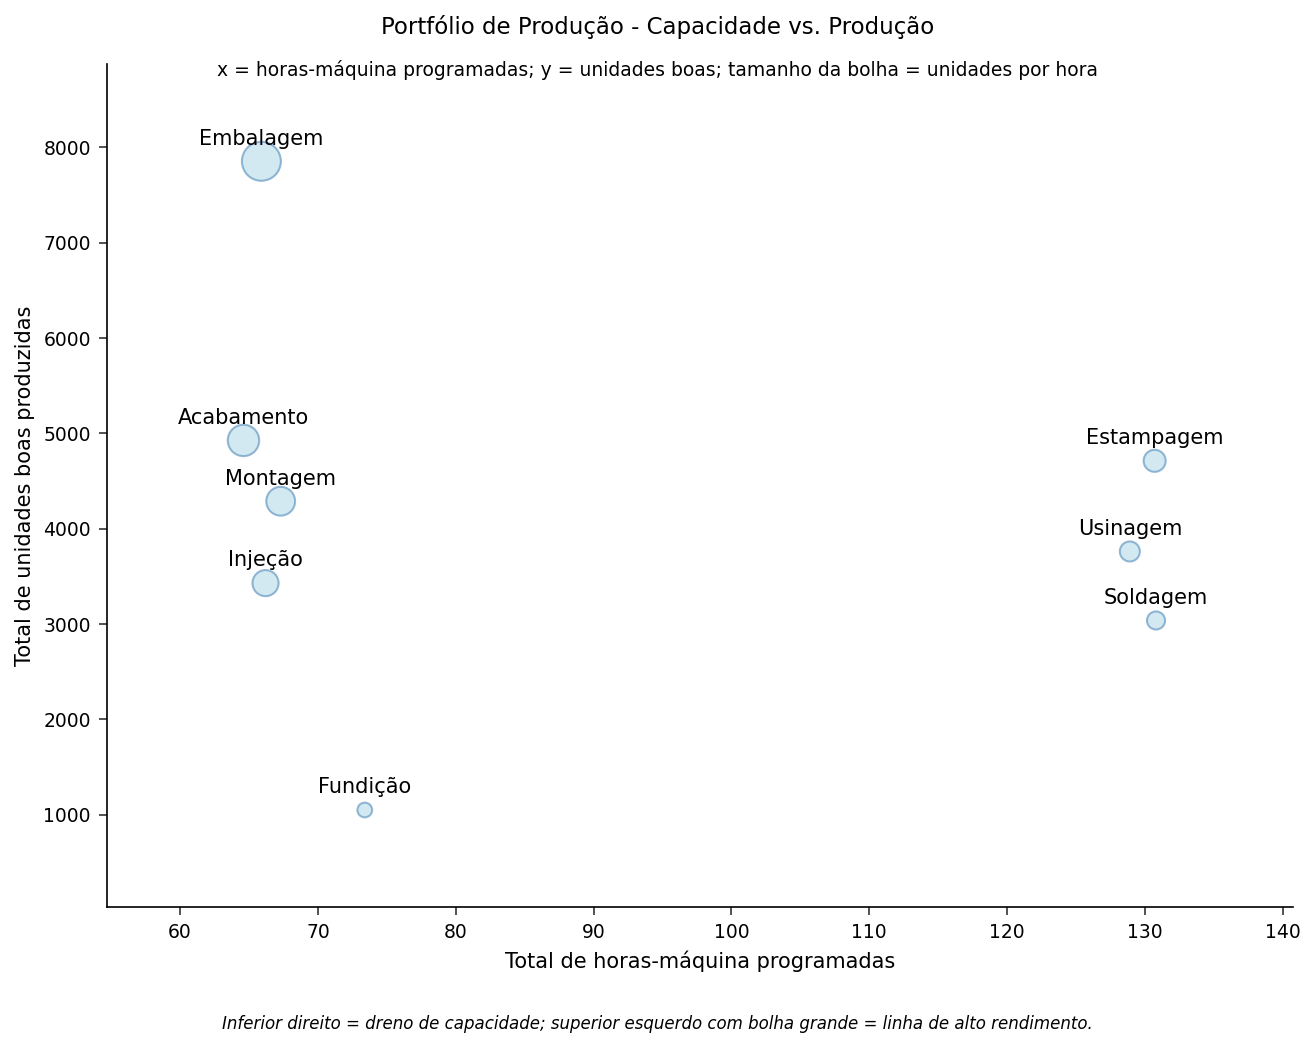

In [4]:
TÍTULO "Portfólio de Produção - Capacidade vs. Produção";
title2 "x = horas-máquina programadas; y = unidades boas; tamanho da bolha = unidades por hora";
footnote JUSTIFY=LEFT
    "Inferior direito = dreno de capacidade; superior esquerdo com bolha grande = linha de alto rendimento.";

PROCEDIMENTO SGPLOT DADOS=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS RÓTULO="Total de horas-máquina programadas";
    YAXIS RÓTULO="Total de unidades boas produzidas";
EXECUTAR;

TÍTULO; title2; footnote;

## 5. Produção por linha, decomposta por fábrica

Para ver como a produção de cada linha se divide entre as três fábricas, um gráfico `VBAR product_line / response=good_units group=plant` empilha as contribuições de cada fábrica dentro de cada barra. Esta é a visão de segmentação: mostra tanto a altura total (unidades boas por linha) quanto a mistura de fábricas dentro de cada barra, para que se possa identificar linhas em que uma fábrica domina a produção.

                               Unidades Boas por Linha de Produto, Empilhadas por Fábrica                               
                     Altura da barra = total de unidades boas; segmentos = contribuição da fábrica                      




NOTE: Option TITLE changed to Unidades Boas por Linha de Produto, Empilhadas por Fábrica.
NOTE: Option TITLE2 changed to Altura da barra = total de unidades boas; segmentos = contribuição da fábrica.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


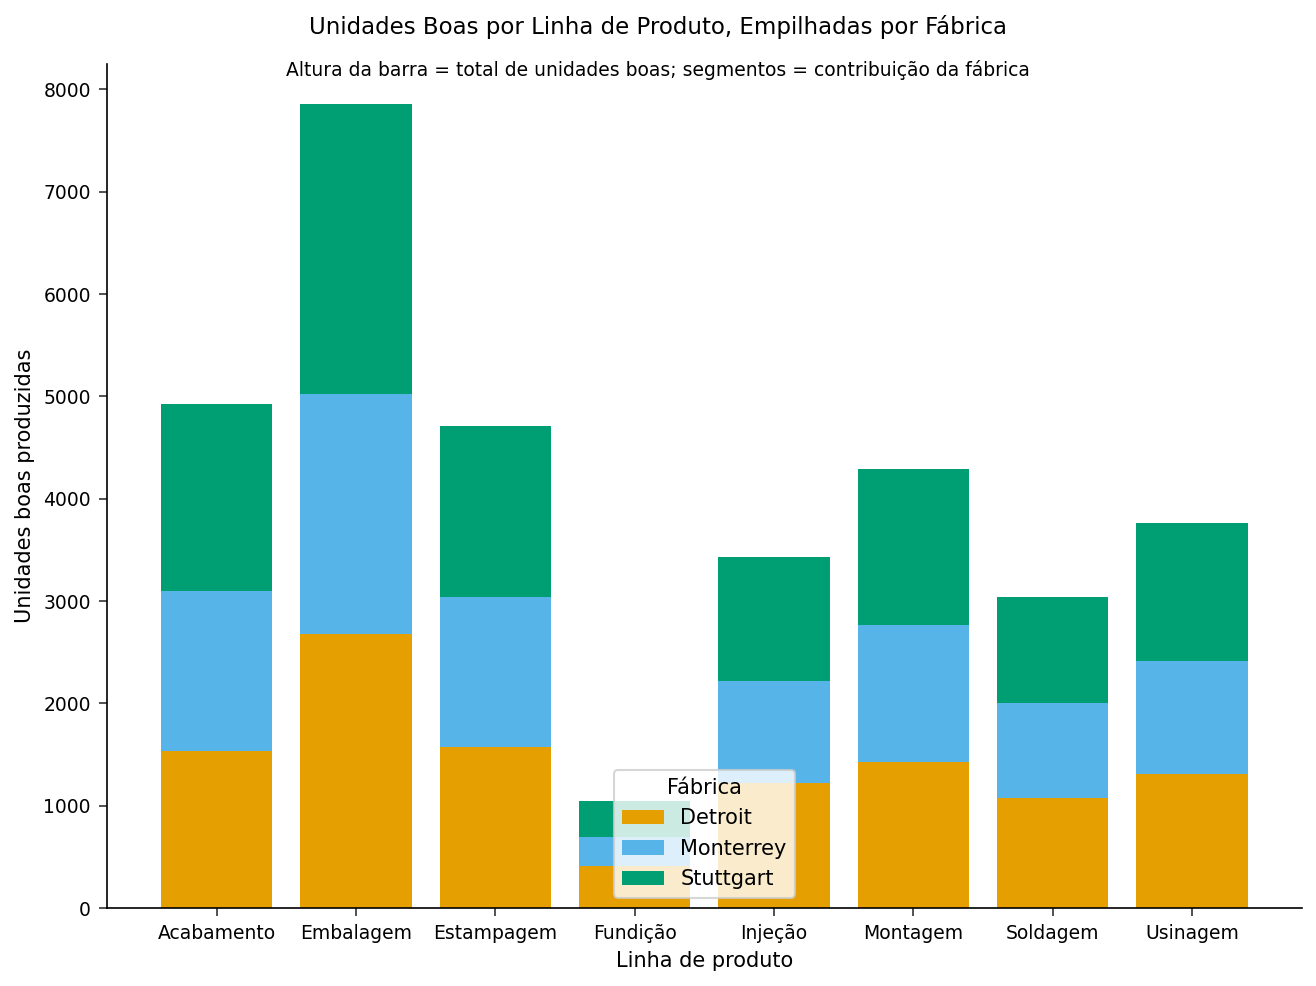

In [5]:
TÍTULO "Unidades Boas por Linha de Produto, Empilhadas por Fábrica";
title2 "Altura da barra = total de unidades boas; segmentos = contribuição da fábrica";

PROCEDIMENTO SGPLOT DADOS=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS RÓTULO="Linha de produto" fitpolicy=ROTATE;
    YAXIS RÓTULO="Unidades boas produzidas";
    keylegend / TÍTULO="Fábrica" position=bottom;
EXECUTAR;

TÍTULO; title2;

## 6. Detalhamento de produtividade de uma única fábrica (WHERE)

Barras horizontais (`HBAR`) são adequadas para rótulos longos de linha de produto. Uma cláusula `WHERE` restringe à fábrica de Stuttgart, e as barras são desenhadas para `units_per_hr`, de modo que o gráfico classifica as linhas de Stuttgart por produtividade. Como a entrada está ordenada de forma crescente pela taxa, a linha menos produtiva fica embaixo e a mais produtiva no topo.

                             Fábrica de Stuttgart - Linhas Classificadas por Produtividade                              


Comprimento da barra = unidades boas por hora-máquina (detalhamento de uma única fábrica).



NOTE: Option TITLE changed to Fábrica de Stuttgart - Linhas Classificadas por Produtividade.
NOTE: Option FOOTNOTE changed to Comprimento da barra = unidades boas por hora-máquina (detalhamento de uma única fábrica)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


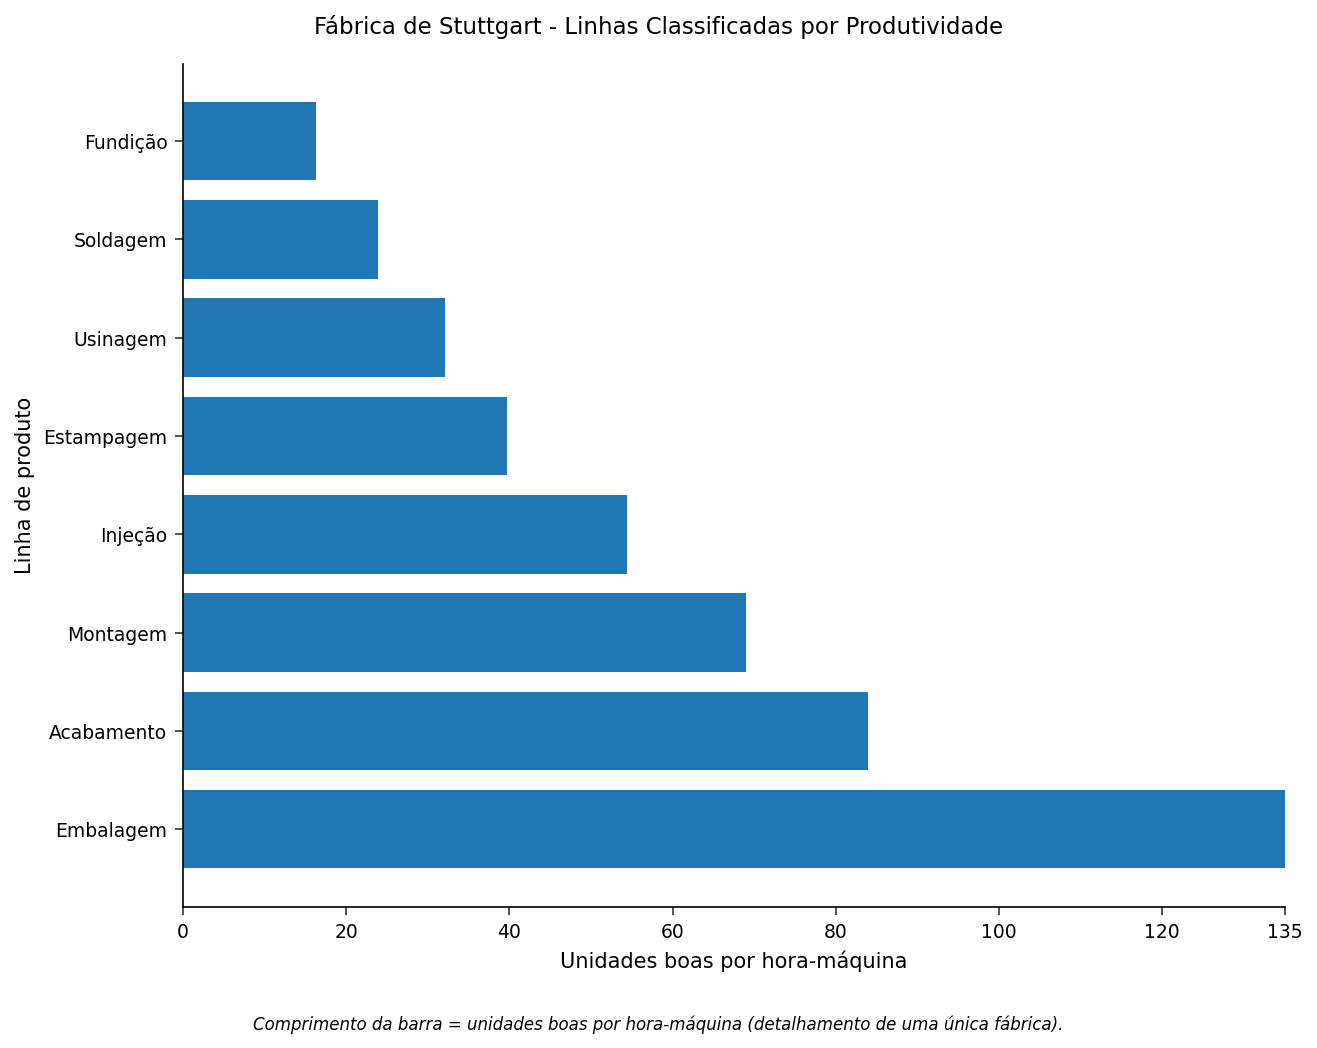

In [6]:
TÍTULO "Fábrica de Stuttgart - Linhas Classificadas por Produtividade";
footnote JUSTIFY=LEFT "Comprimento da barra = unidades boas por hora-máquina (detalhamento de uma única fábrica).";

PROCEDIMENTO SGPLOT DADOS=work.line_capacity;
    ONDE plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS RÓTULO="Unidades boas por hora-máquina";
    YAXIS RÓTULO="Linha de produto";
EXECUTAR;

TÍTULO; footnote;

## 7. Comparação lado a lado das fábricas (barras agrupadas)

Para comparar as três fábricas linha a linha, um gráfico de barras agrupadas (`GROUPDISPLAY=CLUSTER`) desenha Detroit, Monterrey e Stuttgart como barras adjacentes dentro de cada linha de produto. Esta é a visão de comparação direta entre fábricas: para qualquer linha é possível ler qual fábrica produziu mais unidades boas, tornando diretamente visíveis as diferenças de eficiência entre fábricas (Stuttgart mais alta, Monterrey mais baixa).

                                    Unidades Boas por Linha e Fábrica - Lado a Lado                                     
                        Barras agrupadas: uma barra por fábrica dentro de cada linha de produto                         




NOTE: Option TITLE changed to Unidades Boas por Linha e Fábrica - Lado a Lado.
NOTE: Option TITLE2 changed to Barras agrupadas: uma barra por fábrica dentro de cada linha de produto.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


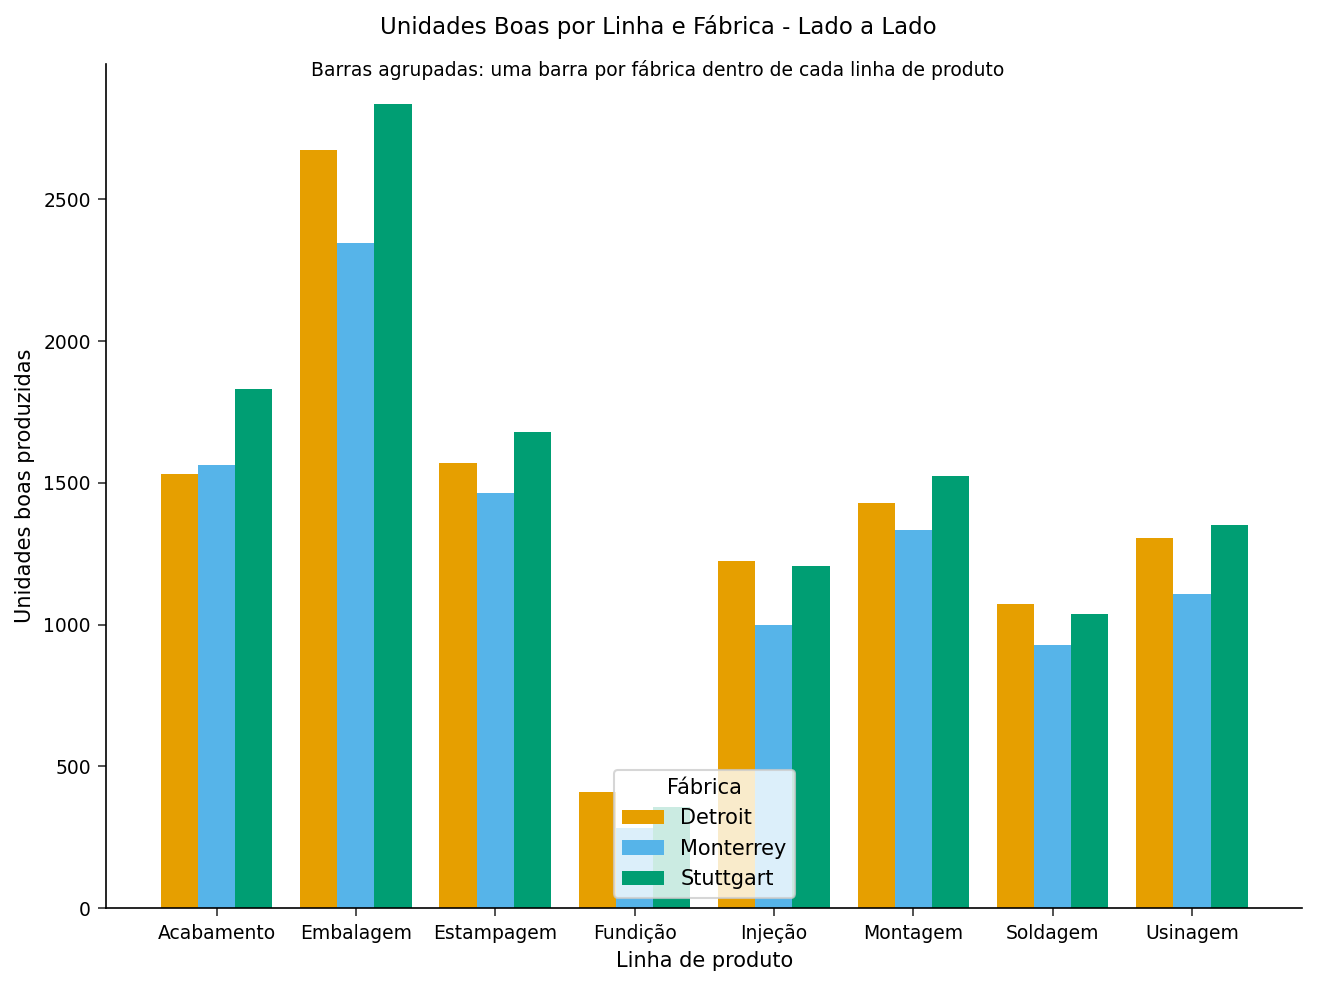

In [7]:
TÍTULO "Unidades Boas por Linha e Fábrica - Lado a Lado";
title2 "Barras agrupadas: uma barra por fábrica dentro de cada linha de produto";

PROCEDIMENTO SGPLOT DADOS=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS RÓTULO="Linha de produto" fitpolicy=ROTATE;
    YAXIS RÓTULO="Unidades boas produzidas";
    keylegend / TÍTULO="Fábrica" position=bottom;
EXECUTAR;

TÍTULO; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Interpretação

Plotar capacidade e produção nos mesmos eixos expõe uma relação que um gráfico de barras unidimensional esconderia. **Fundição** é o dreno de capacidade mais claro do portfólio: no ranking de produtividade ela fica no fundo, com **14.3 unidades boas por hora-máquina**, e no gráfico de bolhas cai para o canto inferior esquerdo como uma bolha pequena — consome **10.1%** do total de horas programadas mas retorna apenas **3.2%** das unidades boas (também carrega o menor rendimento, ~91%, por causa de sua alta fração de refugo). É a principal candidata para kaizen de redução de tempo de ciclo e de refugo. No extremo oposto, **Embalagem** é a linha de alto rendimento em destaque, com **119.2 unidades por hora-máquina** — uma bolha grande, alta no eixo de produção, que transforma **9.1%** da capacidade em **23.8%** de todas as unidades boas; proteger sua disponibilidade rende produção desproporcional. **Acabamento** (76.3 unidades/hora) e **Montagem** (63.7) seguem o mesmo padrão de alto rendimento.

O padrão é sistemático: as quatro linhas lentas e famintas por capacidade a montante — Fundição, Soldagem (23.2 unidades/hora), Usinagem (29.2) e Estampagem (36.1) — juntas consomem cerca de **64%** das horas programadas mas entregam apenas cerca de **38%** das unidades boas, enquanto as quatro linhas rápidas a jusante entregam mais do que as horas que consomem. A visão empilhada por fábrica e as barras agrupadas lado a lado mostram a dimensão de fábrica por trás disso: **Stuttgart** roda mais quente, a **49.9 unidades boas por hora-máquina**, **Detroit** fica no meio, a **44.9**, e **Monterrey** fica atrás, a **41.6** — consistente com o maior tempo de parada modelado de Monterrey. Operacionalmente, isso aponta para realocar horas programadas em direção às linhas de alto rendimento a jusante e comparar o tempo de parada de Monterrey com as práticas de Stuttgart.

*Apenas dados sintéticos — os números são ilustrativos da visualização bidimensional de capacidade vs. produção com PROC SGPLOT, não do desempenho real de uma fábrica.*